# Task 1
## Task 1.1

**Estado elegido: Alabama (`AL`, FIPS `01`).** Tiene 114 hospitales con datos de camas (más del mínimo de 50),
67 condados con mezcla de áreas metropolitanas (Birmingham, Huntsville, Mobile, Montgomery) y condados rurales
del *Black Belt*, y cabe completo en una sola zona UTM, lo que simplifica la medición de distancias.

### a. Carga de los cuatro archivos
Las dependencias están en `requirements.txt`. Para instalarlas (en un entorno virtual):

```bash
python -m venv .venv
.venv\Scripts\activate          # Windows  (Linux/Mac: source .venv/bin/activate)
pip install -r requirements.txt
```

In [1]:
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import shapely
import pyproj
from scipy import stats
from scipy.spatial import cKDTree
from matplotlib_scalebar.scalebar import ScaleBar

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print("geopandas :", gpd.__version__)
print("shapely   :", shapely.__version__)
print("pandas    :", pd.__version__)
print("numpy     :", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("pyproj    :", pyproj.__version__)

geopandas : 1.2.0
shapely   : 2.1.2
pandas    : 3.0.6
numpy     : 2.5.3
matplotlib: 3.11.2
pyproj    : 3.8.0


In [2]:
# ---------------- Parámetros globales del análisis ----------------
STATE = "AL"              # código postal del estado (columna `estado` de hospitales)
STATE_FIPS = "01"         # código FIPS del estado (columna `cod_estado` de condados)
STATE_NAME = "Alabama"
CRS_PROJ = "EPSG:32616"   # WGS 84 / UTM zona 16N (metros) -> justificación en Task 1.1d
RADII_KM = [10, 25, 50]   # radios de buffer del Task 1.3
R_MAP = 25                # radio del mapa de cobertura y del MCLP

# Paleta (categórica en orden fijo; diverging azul<->rojo con gris neutro)
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NEUTRAL = "#f0efec"
TIPO_ES = {"GENERAL ACUTE CARE": "Cuidados agudos generales", "CRITICAL ACCESS": "Acceso crítico",
           "PSYCHIATRIC": "Psiquiátrico", "LONG TERM CARE": "Cuidados a largo plazo",
           "REHABILITATION": "Rehabilitación", "MILITARY": "Militar", "CHILDREN": "Infantil",
           "SPECIAL": "Especial", "WOMEN": "Mujeres", "CHRONIC DISEASE": "Enfermedad crónica", "OTHER": "Otro"}


def add_north_and_scale(ax, loc="lower left"):
    """Escala gráfica (las coordenadas están en metros) y flecha de norte."""
    ax.add_artist(ScaleBar(1, units="m", location=loc, box_alpha=0.8, length_fraction=0.25))
    ax.annotate("N", xy=(0.95, 0.95), xytext=(0.95, 0.85), xycoords="axes fraction",
                ha="center", va="center", fontsize=14, fontweight="bold",
                arrowprops=dict(facecolor="black", width=4, headwidth=12))

In [3]:
hosp_raw = gpd.read_file("hospitales_eeuu.geojson")
counties_raw = gpd.read_file("condados_eeuu.geojson")
states = gpd.read_file("estados_eeuu.geojson")
pop_raw = pd.read_csv("poblacion_condados.csv")

resumen = pd.DataFrame([
    {"archivo": name, "registros": len(df), "CRS": str(df.crs) if isinstance(df, gpd.GeoDataFrame) else "— (tabla)",
     "columnas": ", ".join(df.columns)}
    for name, df in [("hospitales_eeuu.geojson", hosp_raw), ("condados_eeuu.geojson", counties_raw),
                     ("poblacion_condados.csv", pop_raw), ("estados_eeuu.geojson", states)]])
with pd.option_context("display.max_colwidth", 200):
    display(resumen)

,archivo,registros,CRS,columnas
0,hospitales_eeuu.geojson,7154,EPSG:4326,"nombre, tipo, ciudad, estado, condado, fips_condado, camas_total, camas_icu, camas_licenciadas, ocupacion_total, ocupacion_icu, geometry"
1,condados_eeuu.geojson,3221,EPSG:4326,"fips, nombre, cod_estado, geometry"
2,poblacion_condados.csv,3246,— (tabla),"fips, condado, estado, lat, lon, poblacion"
3,estados_eeuu.geojson,51,EPSG:4326,"nombre, codigo, pais, geometry"


### b. Limpieza del dataset completo

1. **Población:** los FIPS ≥ 80000 son registros “Out of XX” (personas reportadas fuera de su condado de
   residencia), no condados reales; se eliminan. Luego `fips` se convierte a texto de 5 dígitos con ceros a la
   izquierda (`1001` → `"01001"`) para que sea compatible con `condados_eeuu.geojson`.
2. **Hospitales:** se reporta el porcentaje de `camas_total` nulo y se conservan solo los hospitales con camas.

In [4]:
n_fake = (pop_raw["fips"] >= 80000).sum()
pop = pop_raw[pop_raw["fips"] < 80000].copy()
pop["fips"] = pop["fips"].astype(int).astype(str).str.zfill(5)
print(f"Población: {len(pop_raw)} registros -> {len(pop)} (eliminados {n_fake} con FIPS >= 80000)")
print(f"  ¿Todos los FIPS tienen 5 dígitos? {pop['fips'].str.len().eq(5).all()} | ejemplo: {pop['fips'].iloc[0]}")
print(f"  Población nula restante: {pop['poblacion'].isna().sum()}")

pct_null = 100 * hosp_raw["camas_total"].isna().mean()
pct_null_st = 100 * hosp_raw.loc[hosp_raw["estado"] == STATE, "camas_total"].isna().mean()
hosp = hosp_raw[hosp_raw["camas_total"].notna()].copy()
print(f"\nHospitales con camas_total nulo: {hosp_raw['camas_total'].isna().sum()} de {len(hosp_raw)} "
      f"= {pct_null:.2f} % (en {STATE_NAME}: {pct_null_st:.2f} %)")
print(f"Hospitales con datos de camas (EE.UU.): {len(hosp)}")
print(f"Hospitales en {STATE_NAME}: {(hosp_raw.estado == STATE).sum()} antes -> {(hosp.estado == STATE).sum()} "
      "después de la limpieza")

Población: 3246 registros -> 3144 (eliminados 102 con FIPS >= 80000)
  ¿Todos los FIPS tienen 5 dígitos? True | ejemplo: 01001
  Población nula restante: 0

Hospitales con camas_total nulo: 1090 de 7154 = 15.24 % (en Alabama: 12.31 %)
Hospitales con datos de camas (EE.UU.): 6064
Hospitales en Alabama: 130 antes -> 114 después de la limpieza


### c. Filtro por estado y unión población–geometría

In [5]:
hosp_st = hosp[hosp["estado"] == STATE].reset_index(drop=True)
cty_geo = counties_raw[counties_raw["cod_estado"] == STATE_FIPS]
pop_st = pop[pop["fips"].str[:2] == STATE_FIPS]
state_geo = states[states["codigo"] == STATE]

# unión 1:1 por la llave FIPS
cty = cty_geo.merge(pop_st[["fips", "poblacion"]], on="fips", how="left", validate="1:1").reset_index(drop=True)
print(f"Condados con geometría : {len(cty_geo)}")
print(f"Condados con población : {len(pop_st)}")
print(f"Condados unidos        : {cty['poblacion'].notna().sum()}  -> ¿coinciden? "
      f"{len(cty_geo) == len(pop_st) == cty['poblacion'].notna().sum()}")
print(f"Población total de {STATE_NAME}: {cty['poblacion'].sum():,.0f}")

# verificación espacial: ¿todos los hospitales caen dentro del límite estatal?
inside_state = hosp_st.within(state_geo.geometry.iloc[0])
print(f"\nHospitales del estado: {len(hosp_st)} | dentro del polígono estatal: {inside_state.sum()}")
print(hosp_st["tipo"].value_counts().rename(index=TIPO_ES).to_string())

Condados con geometría : 67
Condados con población : 67
Condados unidos        : 67  -> ¿coinciden? True
Población total de Alabama: 4,903,185

Hospitales del estado: 114 | dentro del polígono estatal: 113
tipo
Cuidados agudos generales    84
Psiquiátrico                  9
Cuidados a largo plazo        6
Rehabilitación                6
Acceso crítico                4
Militar                       3
Infantil                      2


### d. Reproyección y justificación del CRS

**CRS elegido: EPSG:32616 — WGS 84 / UTM zona 16N.**

Alabama se extiende de ≈ 88.5° O a 84.9° O, completamente dentro de la zona UTM 16 (90° O – 84° O, meridiano
central 87° O). UTM es una Transversa de Mercator **conforme** cuyo factor de escala solo depende de la distancia
al meridiano central: $k \approx k_0\left(1 + \tfrac{(\Delta\lambda\cos\varphi)^2}{2}\right)$, $k_0 = 0.9996$. Con
$\Delta\lambda \le 2.1°$ el error de escala no supera ~0.04 %. Abajo se compara con otras opciones evaluando el
error de escala real (`pyproj`) en una grilla sobre el estado y ponderado por la población de cada condado.

In [6]:
cty_p0 = cty.to_crs(CRS_PROJ)
gx, gy = np.meshgrid(np.linspace(*cty_p0.total_bounds[[0, 2]], 60), np.linspace(*cty_p0.total_bounds[[1, 3]], 60))
grid_pts = gpd.GeoSeries(gpd.points_from_xy(gx.ravel(), gy.ravel()), crs=CRS_PROJ)
grid_pts = grid_pts[grid_pts.within(cty_p0.union_all())].to_crs("EPSG:4326")
cent_ll = cty_p0.geometry.centroid.to_crs("EPSG:4326")

rows = []
for epsg, desc in [(32616, "UTM 16N (WGS84)"), (26929, "State Plane Alabama Este"),
                   (26930, "State Plane Alabama Oeste"), (5070, "Albers EE.UU. contiguo")]:
    proj = pyproj.Proj(f"EPSG:{epsg}")
    def err(lon, lat):
        f = proj.get_factors(lon, lat)
        return 100 * np.maximum(np.abs(f.meridional_scale - 1), np.abs(f.parallel_scale - 1))
    rows.append({"CRS": f"EPSG:{epsg}", "descripción": desc,
                 "error escala máx (%)": err(grid_pts.x.values, grid_pts.y.values).max(),
                 "error medio ponderado por población (%)": np.average(err(cent_ll.x.values, cent_ll.y.values),
                                                                       weights=cty["poblacion"])})
pd.DataFrame(rows).set_index("CRS")

,descripción,error escala máx (%),error medio ponderado por población (%)
CRS,,,
EPSG:32616,UTM 16N (WGS84),0.04,0.03
EPSG:26929,State Plane Alabama Este,0.07,0.01
EPSG:26930,State Plane Alabama Oeste,0.06,0.01
EPSG:5070,Albers EE.UU. contiguo,0.85,0.61


In [7]:
hosp_p = hosp_st.to_crs(CRS_PROJ)
cty_p = cty.to_crs(CRS_PROJ)
state_p = state_geo.to_crs(CRS_PROJ)
state_poly = state_p.geometry.iloc[0]
for name, g in [("hospitales", hosp_p), ("condados", cty_p), ("estado", state_p)]:
    print(f"{name:<11} -> {g.crs}")
cty_p["area_km2"] = cty_p.area / 1e6
print(f"Área total de los condados: {cty_p['area_km2'].sum():,.0f} km²")

hospitales  -> EPSG:32616
condados    -> EPSG:32616
estado      -> EPSG:32616
Área total de los condados: 133,785 km²


### e. Mapa base de tres capas

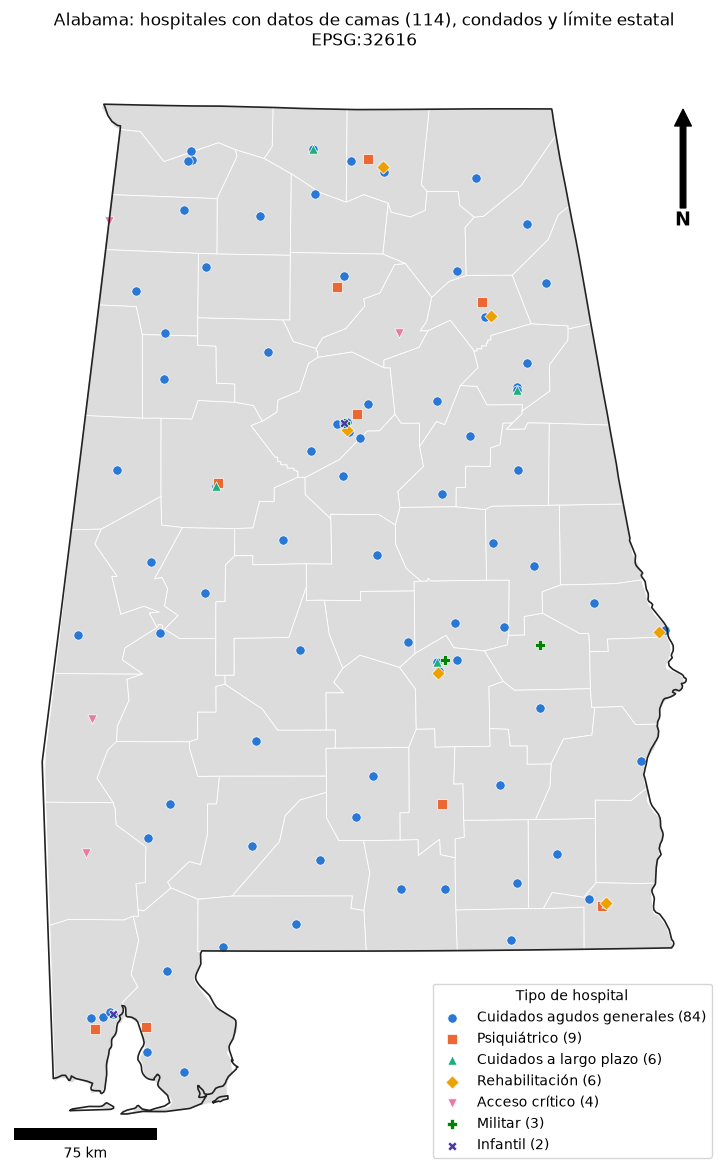

In [8]:
tipos_orden = hosp_p["tipo"].value_counts().index.tolist()
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
fig, ax = plt.subplots(figsize=(10, 12))
cty_p.plot(ax=ax, color="#dcdcdc", edgecolor="white", linewidth=0.6)
for i, t in enumerate(tipos_orden):
    sub = hosp_p[hosp_p["tipo"] == t]
    sub.plot(ax=ax, color=CAT[i], marker=markers[i], markersize=45, edgecolor="white", linewidth=0.5,
             label=f"{TIPO_ES.get(t, t)} ({len(sub)})", zorder=3)
state_p.boundary.plot(ax=ax, color="#222222", linewidth=1.2, zorder=4)
ax.legend(title="Tipo de hospital", loc="lower right", frameon=True)
add_north_and_scale(ax)
ax.set_title(f"{STATE_NAME}: hospitales con datos de camas ({len(hosp_p)}), condados y límite estatal\n"
             f"{CRS_PROJ}", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()